# Results

## Notes Analysis
 - Precision, Recall, Specificity, AUROC, Accuracy using thresholds (.5, .955)

## Patient Analysis
 - Precision, Recall, Specificity, AUROC, Accuracy using thresholds = .955 
 - ROC Curve
 - Confusion Matrix

![](notes-label.png)

In [10]:
import sys
import numpy as np
from functools import wraps
from typing import overload
import datetime as dt
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
from pathlib import Path
from seaborn import axes_style
from sklearn.metrics import precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.utils import resample
from sklearn.metrics import roc_curve, auc, confusion_matrix
from notebook_utils import get_parent_dir

sys.path.append(str(get_parent_dir() / "PINES"))

from train_finetune import (
    start_pipeline,
    logg
)

In [11]:
IN_DIR = get_parent_dir() / "In"
OUT_DIR = get_parent_dir() / "Out"

In [12]:
@logg
def get_results(dataf):
    dataf["date"] = pd.to_datetime(dataf["date"])
    return dataf

@logg
def get_events(dataf):
    columns=["MRN", "CANCER_VTE_DATE"]
    dataf = dataf[columns].copy()
    dataf["CANCER_VTE_DATE"] = pd.to_datetime(dataf["CANCER_VTE_DATE"])
    dataf.columns = ["patient_id", "CANCER_VTE_DATE"]
    dev_ids = pd.read_csv(IN_DIR / "dev_ids.csv")
    return dataf.merge(dev_ids) 


In [13]:
def get_scores(y_true, y_prob, threshold=0.955, n_bootstrap_samples=1000, confidence_level=.95):

    # Initialize lists to store the bootstrapped metrics
    precision_scores = []
    recall_scores = []
    specificity_scores = []
    roc_auc_scores = []
    acc_score = []

    for _ in range(n_bootstrap_samples):
        # Create a bootstrap sample
        bootstrap_indices = resample(np.arange(len(y_true)), replace=True)
        bootstrap_y_true = y_true[bootstrap_indices]
        bootstrap_y_prob = y_prob[bootstrap_indices]

        # Compute the prediction based on the chosen threshold
        bootstrap_y_pred = (bootstrap_y_prob >= threshold).astype(int)

        # Compute the metrics on the bootstrap sample
        precision = precision_score(bootstrap_y_true, bootstrap_y_pred)
        recall = recall_score(bootstrap_y_true, bootstrap_y_pred)
        tn, fp, fn, tp = confusion_matrix(bootstrap_y_true, bootstrap_y_pred).ravel()
        specificity = tn / (tn+fp)
        roc_auc = roc_auc_score(bootstrap_y_true, bootstrap_y_prob)
        acc = (bootstrap_y_true == bootstrap_y_pred).sum()/len(bootstrap_y_true)

        # Store the metrics
        precision_scores.append(precision)
        recall_scores.append(recall)
        specificity_scores.append(specificity)
        roc_auc_scores.append(roc_auc)
        acc_score.append(acc)

    # Compute the confidence intervals
    lower = (1.0-confidence_level)/2.0 * 100
    upper = (confidence_level+((1.0-confidence_level)/2.0)) * 100

    precision_ci = np.percentile(precision_scores, [lower, upper]).round(2)
    recall_ci = np.percentile(recall_scores, [lower, upper]).round(2)
    specificity_ci = np.percentile(specificity_scores, [lower, upper]).round(2)
    roc_auc_ci = np.percentile(roc_auc_scores, [lower, upper]).round(2)
    acc_ci = np.percentile(acc_score, [lower, upper]).round(2)

    metrics_df = {
        "Precision": [f"{np.mean(precision_scores).round(2)} {tuple(precision_ci)}"],
        "Recall": [f"{np.mean(recall_scores).round(2)} {tuple(recall_ci)}"],
        "Specificity": [f"{np.mean(specificity_scores).round(2)} {tuple(specificity_ci)}"],
        "ROC AUC": [f"{np.mean(roc_auc_scores).round(2)} {tuple(roc_auc_ci)}"],
        "Accuracy": [f"{np.mean(acc_score).round(2)} {tuple(acc_ci)}"]
    }
    
    print(f'Precision: {np.mean(precision_scores).round(2)} CI: {precision_ci}')
    print(f'Recall: {np.mean(recall_scores).round(2)} CI: {recall_ci}')
    print(f'Specificity: {np.mean(specificity_scores).round(2)} CI: {specificity_ci}')
    print(f'ROC AUC: {np.mean(roc_auc_scores).round(2)} CI: {roc_auc_ci}')
    print(f'Accuracy: {np.mean(acc_score).round(2)} CI: {acc_ci}')
    
    return pd.DataFrame.from_dict(metrics_df)

In [14]:
def plot_roc(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    p = (
        so.Plot(fpr, tpr)
        .add(so.Line(color='orange'))
        .label(
            x="False Positive Rate",
            y="True Positive Rate",
            col="asda",
            color=str.capitalize,
            # title="ROC on Test Set (AUC: {})".format(round(roc_auc,2)),
        )
        .theme({**axes_style("whitegrid"),
        # "legend.loc": "best",
        "font.weight": "bold",
        "font.size": 40,
        "axes.titlesize" : 20,
        "axes.titleweight": "bold"
       })
    )
    f, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlabel("a", fontsize=20, fontweight='bold')
    ax.set_ylabel("a", fontsize=20, fontweight='bold')
    sns.lineplot([0, 1],linestyle='--', color='blue', ax=ax)
    ax.text(.7,0,f"AUC: {round(roc_auc,2)}",  fontsize=20, fontweight='bold')
    (p.on(ax)
        .save("roc_pines.svg",
           dpi=300,
           format="svg",
           bbox_inches="tight",
         )
    )

In [9]:
def plot_confusion_matrix(y_true, y_prob, thresh=0.955):
    # Generate the confusion matrix
    cm = confusion_matrix(y_true, y_prob>thresh)
    class_names= ["VTE Absent", "VTE Present"]
    f, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    
    mpl.rcParams['font.weight'] = 'bold'
    mpl.rcParams['font.size'] = 20
    # Add labels to the plot
    plt.xlabel('Predicted label',  fontsize=24, fontweight='bold')
    plt.ylabel('True label',  fontsize=24, fontweight='bold')
    # plt.title('Confusion Matrix (PINES)',  fontsize=20, fontweight='bold')
    plt.savefig("pines_confusion_matrix.svg", dpi=300, format="svg", bbox_inches="tight")

    # The confusion matrix is a 2x2 array. You can print it as is
    print(cm)

    # If you want to print it with labels
    tn, fp, fn, tp = cm.ravel()

    print(f'True Positives: {tp}')
    print(f'False Positives: {fp}')
    print(f'True Negatives: {tn}')
    print(f'False Negatives: {fn}')

In [15]:
results_df = pd.read_csv(OUT_DIR / "predictions_model_abstract_dev.csv")
results_df = results_df.pipe(start_pipeline).pipe(get_results)

events = pd.read_parquet(IN_DIR / "prepped_core_7_21_2022.parquet")
events_dev = events.pipe(start_pipeline).pipe(get_events)

patient_results = results_df.groupby("patient_id")["proba"].max().reset_index().merge(
    results_df.groupby("patient_id")["label"].max().reset_index())

all_patient_results = events_dev[["patient_id"]].merge(patient_results, how="left").fillna(0.0)

start_pipeline took=0:00:00.000663 shape=(60134, 5)
get_results took=0:00:00.008051 shape=(60134, 5)
start_pipeline took=0:00:00.058082 shape=(35391, 1505)
get_events took=0:00:00.011897 shape=(3540, 2)


## Notes level analysis

In [16]:
df_notes_metrics_955 = get_scores(results_df.label, results_df.proba, threshold=0.955)
df_notes_metrics_955["type"] = "notes@0.955"

Precision: 0.96 CI: [0.96 0.97]
Recall: 0.68 CI: [0.67 0.69]
Specificity: 0.99 CI: [0.98 0.99]
ROC AUC: 0.94 CI: [0.94 0.95]
Accuracy: 0.88 CI: [0.87 0.88]


In [17]:
df_notes_metrics_5 = get_scores(results_df.label, results_df.proba, threshold=.5)
df_notes_metrics_5["type"] = "notes@0.5"

Precision: 0.88 CI: [0.88 0.89]
Recall: 0.85 CI: [0.85 0.86]
Specificity: 0.94 CI: [0.94 0.94]
ROC AUC: 0.94 CI: [0.94 0.95]
Accuracy: 0.91 CI: [0.91 0.91]


## Patient level analysis

In [18]:
df_pt_metrics = get_scores(all_patient_results.label, all_patient_results.proba)
df_pt_metrics["type"] = "patients@.955"

Precision: 0.82 CI: [0.78 0.85]
Recall: 0.95 CI: [0.92 0.96]
Specificity: 0.97 CI: [0.96 0.97]
ROC AUC: 0.99 CI: [0.99 1.  ]
Accuracy: 0.96 CI: [0.96 0.97]


In [19]:
pd.concat([df_notes_metrics_955, df_notes_metrics_5, df_pt_metrics]).to_csv("metrics.csv")

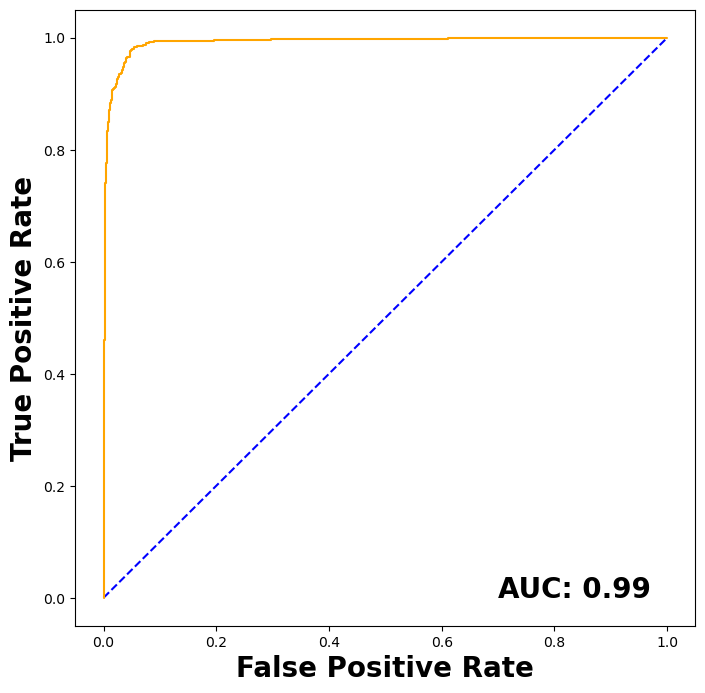

In [20]:
plot_roc(all_patient_results.label, all_patient_results.proba)

[[2946  103]
 [  27  464]]
True Positives: 464
False Positives: 103
True Negatives: 2946
False Negatives: 27


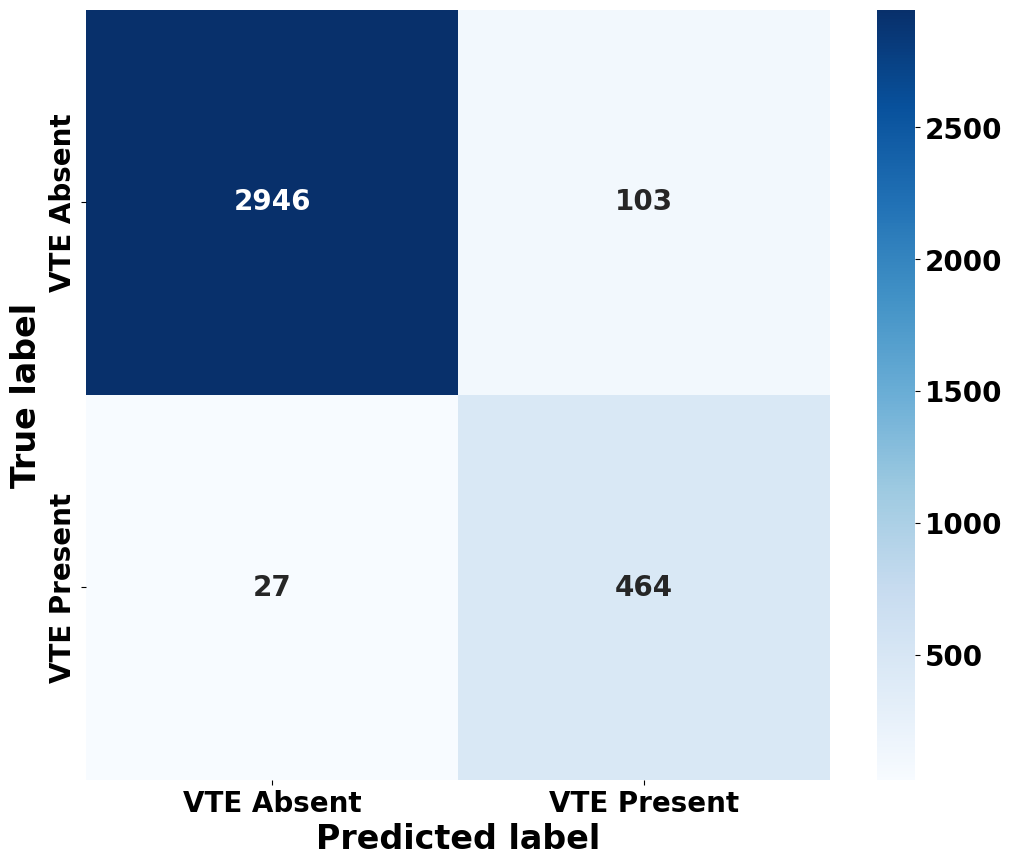

In [23]:
plot_confusion_matrix(all_patient_results.label, all_patient_results.proba);

## Training Plots

In [25]:
val_loss = pd.read_csv(OUT_DIR / "val_loss.csv")
val_acc = pd.read_csv(OUT_DIR / "val_acc.csv")

In [26]:
val_loss.Step = (val_loss.Step + 1) // 1000
val_loss["steps"] = val_loss.Step.apply(lambda x: "".join([str(x), "K"]))

In [27]:
val_acc.Step = (val_acc.Step + 1) // 1000
val_acc["steps"] = val_acc.Step.apply(lambda x: "".join([str(x), "K"]))

In [28]:
def plot_line(df, fname, x='Step', y="Loss"):
    p = (
        so.Plot(df.steps, df.Value)
        .add(so.Line(color='orange'))
        .label(
            x="Step",
            y=y,
            col="asda",
            color=str.capitalize,
            # title="ROC on Test Set (AUC: {})".format(round(roc_auc,2)),
        )
        .theme({**axes_style("whitegrid"),
        "legend.loc": "best",
        "font.weight": "bold",
        "font.size": 40,
        "axes.titlesize" : 20,
        "axes.titleweight": "bold"
       })
    )
    f, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlabel("a", fontsize=20, fontweight='bold')
    ax.set_ylabel("a", fontsize=20, fontweight='bold')
    (p.on(ax)
        .save(f"{fname}.svg",
           dpi=300,
           format="svg",
           bbox_inches="tight",
         )
    )
    return p

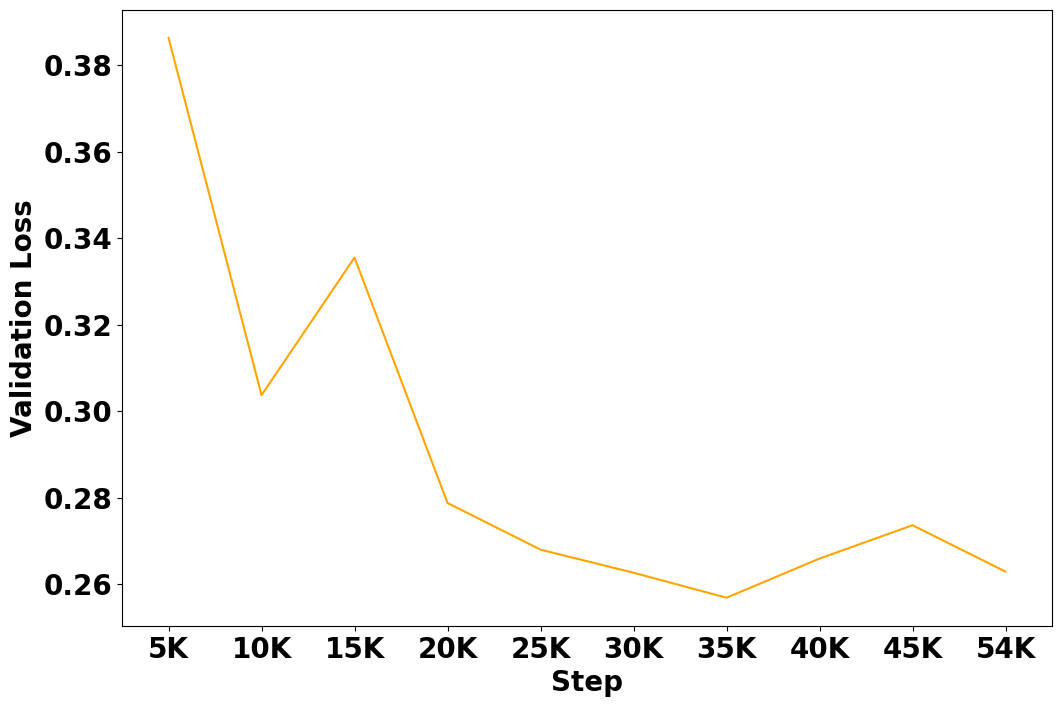

In [29]:
plot_line(val_loss, fname="val_loss", y="Validation Loss");

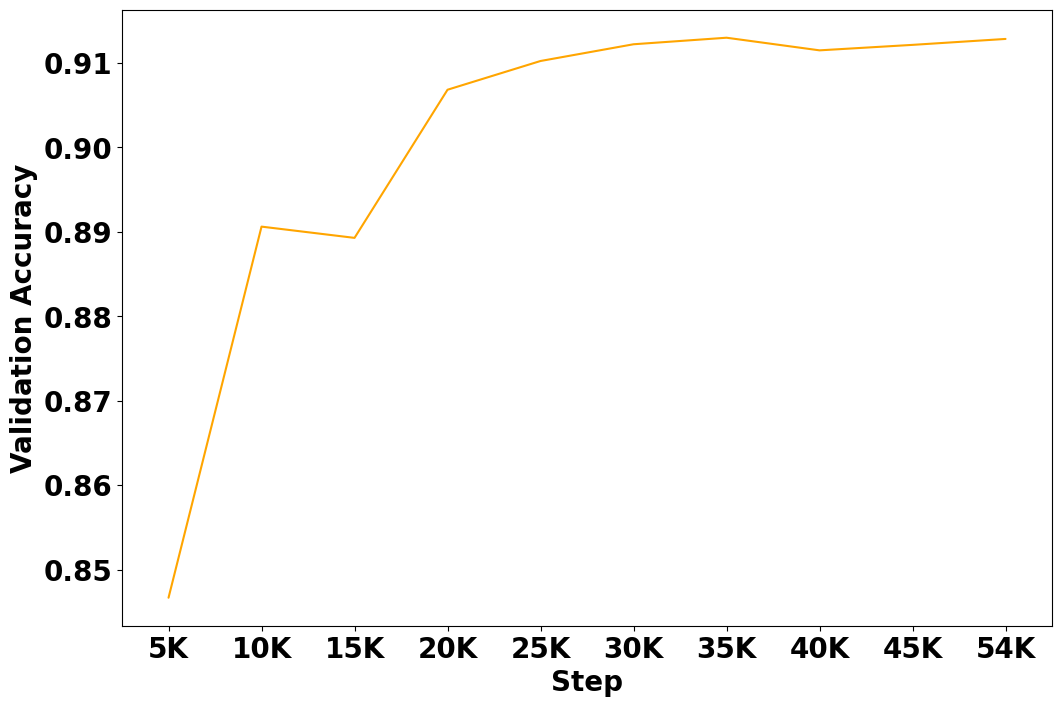

In [30]:
plot_line(val_acc, fname="val_acc", y="Validation Accuracy");